In [39]:
import psycopg2
import pandas as pd
import networkx as nx
import base58
import matplotlib.pyplot as plt
import re
import math
import matplotlib.dates as mdates
import networkx as nx
from collections import defaultdict
from networkx.algorithms.approximation import max_clique
from itertools import combinations
import numpy as np
from networkx.algorithms.coloring import greedy_color
import random

In [2]:
# Connect to PostgreSQL and fetch data
conn = psycopg2.connect(
    dbname="sui_indexer",
    user="postgres",
    password="56904628",
    host="172.26.112.1",
    port=5432
)
cur = conn.cursor()

Count transactions

In [5]:
cur.execute("""
SELECT
    (SELECT COUNT(*) FROM transactions) AS total_tx,
    (SELECT SUM(user_tx_count) FROM checkpoints) AS user_tx,
    (SELECT SUM(system_tx_count) FROM checkpoints) AS system_tx,
    (SELECT COUNT(*) FROM checkpoints) AS total_checkpoints;
""")

total_tx, user_tx, system_tx, total_checkpoints = cur.fetchone()

print("Total transactions:", total_tx)
print("Total user tx:", user_tx)
print("Total system tx:", system_tx)
print("Total checkpoints:", total_checkpoints)


Total transactions: 816888
Total user tx: 806951
Total system tx: 12483
Total checkpoints: 12482


In [131]:
cur.execute("SELECT COUNT(*) FROM object_changes;")
total_object_changes = cur.fetchone()[0]
print("Total object changes:", total_object_changes)

Total object changes: 1735357


In [79]:
cur.execute("""SELECT digest FROM checkpoints WHERE sequence_number = '9981495';""")
hex_str = cur.fetchone()[0].hex()
digest_bytes = bytes.fromhex(hex_str)
base58_str = base58.b58encode(digest_bytes).decode()
print(base58_str)

He9XVLs6GkxjWXE46N1CKPwbpPiJaN6w76yMiQC6qJ9C


In [96]:
cur.execute("""SELECT sequence_number, timestamp
FROM checkpoints
ORDER BY sequence_number DESC
LIMIT 1;""")

sequence_number, timestamp = cur.fetchone()

print("Latest checkpoint sequence number:", sequence_number)
print("Latest checkpoint timestamp:", timestamp)


Latest checkpoint sequence number: 13398490
Latest checkpoint timestamp: 2023-09-19 17:56:49.228000+01:00


In [97]:
cur.execute("""SELECT * FROM watermarks WHERE pipeline = 'checkpoint_handler';""")
temp = cur.fetchall()
temp

[('checkpoint_handler',
  160,
  13401099,
  797645436,
  1695145234146,
  0,
  datetime.datetime(1970, 1, 1, 0, 0),
  0)]

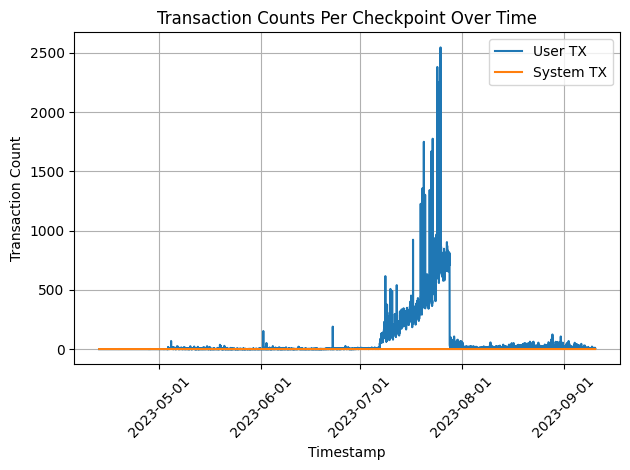

In [8]:
cur.execute("SELECT timestamp, user_tx_count, system_tx_count FROM checkpoints ORDER BY timestamp;")

rows = cur.fetchall()

df = pd.DataFrame(rows, columns=[
    "timestamp",
    "user_tx_count",
    "system_tx_count"
])

df["timestamp"] = pd.to_datetime(df["timestamp"])

plt.figure()
plt.plot(df["timestamp"], df["user_tx_count"], label="User TX")
plt.plot(df["timestamp"], df["system_tx_count"], label="System TX")

plt.xlabel("Timestamp")
plt.ylabel("Transaction Count")
plt.title("Transaction Counts Per Checkpoint Over Time")
plt.legend()
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

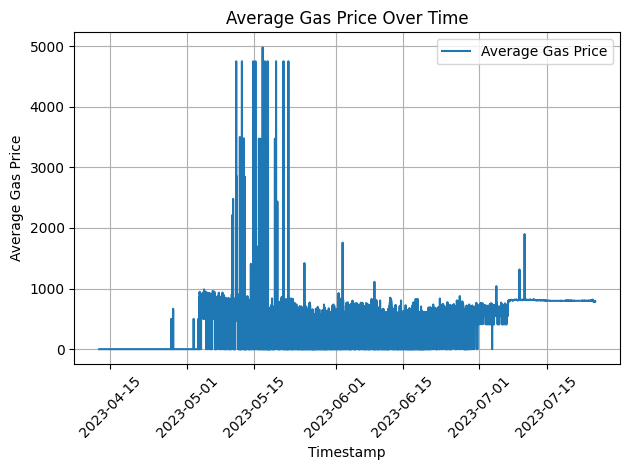

In [61]:
cur.execute("""
    SELECT 
        c.timestamp,
        AVG(t.gas_price) AS avg_gas_price
    FROM transactions t
    JOIN checkpoints c
        ON t.checkpoint_sequence = c.sequence_number
    GROUP BY c.timestamp
    ORDER BY c.timestamp;
""")

rows = cur.fetchall()

df = pd.DataFrame(rows, columns=["timestamp", "avg_gas_price"])

df["timestamp"] = pd.to_datetime(df["timestamp"])

plt.figure()
plt.plot(df["timestamp"], df["avg_gas_price"], label="Average Gas Price")

plt.xlabel("Timestamp")
plt.ylabel("Average Gas Price")
plt.title("Average Gas Price Over Time")
plt.legend()
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [48]:
def shorten_error(err):

    # Force bytes → str safely
    if isinstance(err, bytes):
        err = err.decode("utf-8", errors="replace")
    else:
        err = str(err)

    # Case 1: If Abort Code actually exists (clean numeric label)
    match = re.search(r"Abort Code[:\s]+(\d+)", err)
    if match:
        code = match.group(1)
        return f"Move Abort Code {code}"

    # Case 2: Your CURRENT format: "Move Runtime Abort, Location: <hex>..."
    if "Move Runtime Abort" in err and "Location:" in err:
        # Extract first 8 hex chars after Location:
        hex_match = re.search(r"Location:\s*([0-9a-fA-F]{6,})", err)
        if hex_match:
            short_hex = hex_match.group(1)[:8]
            return f"Move {short_hex}"

        return "Move Runtime Abort"

    if "Insufficient Gas" in err:
        return "Insufficient Gas"

    if "Insufficient coin balance" in err:
        return "Insufficient Balance"

    return err[:30] + "..."


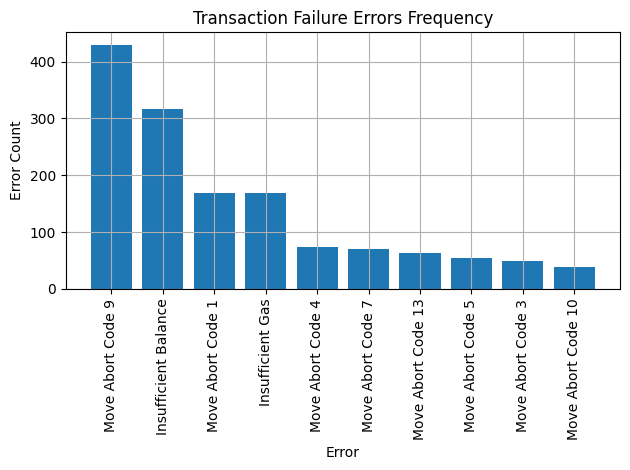

In [ ]:
cur.execute("SELECT error FROM transactions WHERE status = 'failure';")

cur.execute("""
    SELECT error, COUNT(*) 
    FROM transactions
    WHERE status = 'failure'
      AND error IS NOT NULL
    GROUP BY error
    ORDER BY COUNT(*) DESC
    LIMIT 10;
""")

rows = cur.fetchall()

decoded_errors = []
counts = []

for error_bytes, count in rows:
    hex_str = error_bytes.hex()
    error_string = bytes.fromhex(hex_str)

    decoded_errors.append(error_string)
    counts.append(count)

df = pd.DataFrame({
    "error": decoded_errors,
    "count": counts
})

df["short_error"] = df["error"].apply(shorten_error)

plt.figure()
plt.bar(df["short_error"], df["count"])

plt.xlabel("Error")
plt.ylabel("Error Count")
plt.title("Top 10 Transaction Failure Errors")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

Concurrent write operations

In [12]:
cur.execute("""SELECT
    oc1.transaction_digest AS tx1,
    oc2.transaction_digest AS tx2,
    oc1.address,
    c.sequence_number AS checkpoint
FROM object_changes oc1
JOIN object_changes oc2
    ON oc1.address = oc2.address
    AND oc1.transaction_digest < oc2.transaction_digest
JOIN transactions t1
    ON oc1.transaction_digest = t1.transaction_digest
JOIN transactions t2
    ON oc2.transaction_digest = t2.transaction_digest
JOIN checkpoints c
    ON t1.checkpoint_sequence = c.sequence_number
    AND t2.checkpoint_sequence = c.sequence_number
WHERE
    -- BOTH are write operations
    oc1.change_type IS NOT NULL
    AND oc2.change_type IS NOT NULL;""")

rows = cur.fetchall()
len(rows)

256255

Create concurrent WRITE graphs

In [13]:
# Group edges by checkpoint
graphs = defaultdict(nx.Graph)

for tx1, tx2, object_address, checkpoint in rows:
    G = graphs[checkpoint]
    G.add_edge(tx1.hex(), tx2.hex(), object=object_address.hex())

# graphs[checkpoint] = NetworkX conflict graph for that checkpoint
print(f"Built {len(graphs)} checkpoint graphs")

Built 4072 checkpoint graphs


Visualize one graph

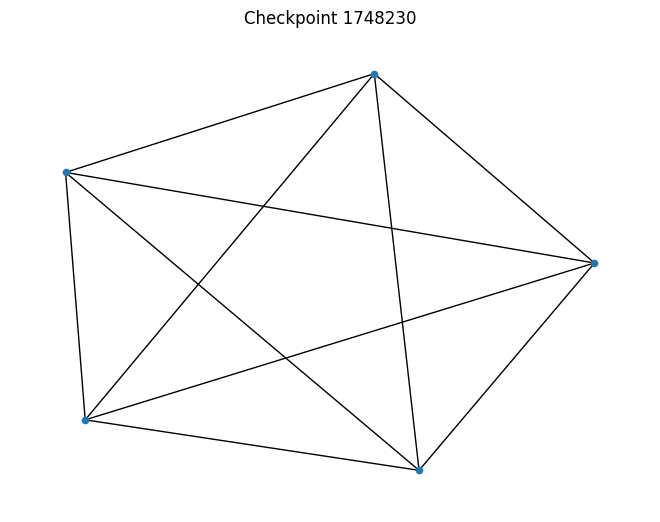

In [34]:
cp = list(graphs.keys())[0]
G = graphs[cp]

plt.figure()
nx.draw(G, node_size=20, with_labels=False)
plt.title(f"Checkpoint {cp}")
plt.show()

Visualize the graph with more concurrent writes

Random checkpoint with > 150 transactions: 8161401
Number of transactions (nodes): 432
Number of concurrent write edges: 313


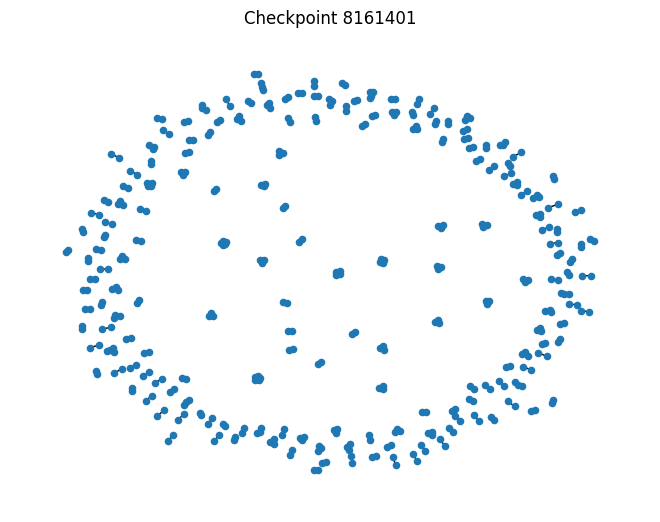

In [63]:
# Set your minimum size threshold here
N = 150

# Find all checkpoints whose graph has more than N nodes with high density
eligible_cps = [
    cp for cp, G in graphs.items()
    if G.number_of_nodes() > N #and G.number_of_edges() > 5 * N
]

if not eligible_cps:
    print(f"No checkpoint found with more than {N} nodes.")
else:
    # Randomly select one
    cp_rand = random.choice(eligible_cps)
    G_rand = graphs[cp_rand]

    print(f"Random checkpoint with > {N} transactions: {cp_rand}")
    print(f"Number of transactions (nodes): {G_rand.number_of_nodes()}")
    print(f"Number of concurrent write edges: {G_rand.number_of_edges()}")

    plt.figure()
    nx.draw(G_rand, node_size=20, with_labels=False)
    plt.title(f"Checkpoint {cp_rand}")
    plt.show()

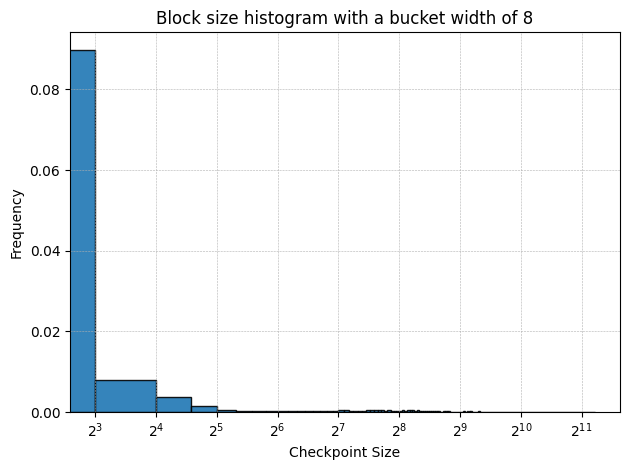

In [107]:
cur.execute("""
    SELECT checkpoint_sequence, COUNT(*) AS size
    FROM transactions
    GROUP BY checkpoint_sequence
    ORDER BY checkpoint_sequence;
""")
rows = cur.fetchall()

df = pd.DataFrame(rows, columns=["checkpoint", "size"])
sizes = df["size"].values

# Create bucket width of 8
max_size = sizes.max()
bin_edges = np.arange(0, max_size + 8, 8)

# Plot histogram with those bins
counts, bins, patches = plt.hist(
    sizes,
    bins=bin_edges,
    density=True,
    edgecolor="black",
    alpha=0.9
)

# Log2 x-axis (paper-style)
plt.xscale("log", base=2)
plt.xlabel("Checkpoint Size")
plt.ylabel("Frequency")
plt.title("Block size histogram with a bucket width of 8")

plt.grid(True, which="both", linestyle="--", linewidth=0.4)
plt.tight_layout()
plt.show()


In [108]:
# Approximate pure value transfer transactions
cur.execute("""SELECT checkpoint_sequence, transaction_digest
FROM transactions
WHERE kind = 'ProgrammableTransaction'
  AND command_move_call = 0
  AND command_publish = 0
  AND command_upgrade = 0
  AND command_make_move_vec = 0
  AND (
        command_transfer_objects > 0 OR
        command_split_coins > 0 OR
        command_merge_coins > 0
      );""")
rows = cur.fetchall()

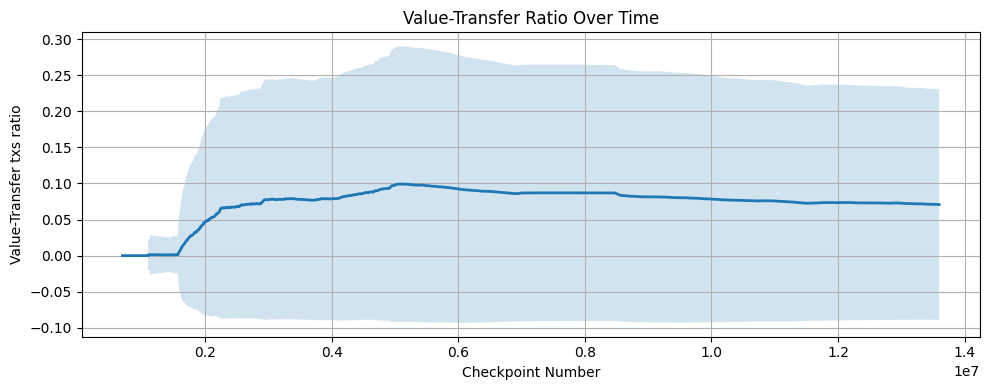

In [109]:

# Load ALL transactions for computing total per checkpoint
cur.execute("SELECT checkpoint_sequence, transaction_digest FROM transactions;")
all_tx = cur.fetchall()

df_all = pd.DataFrame(all_tx, columns=["checkpoint", "digest"])

# Load pure value transfer transactions (you already computed rows)
df_pure = pd.DataFrame(rows, columns=[desc.name for desc in cur.description])

# Keep only checkpoint + digest
df_pure = df_pure[["checkpoint_sequence", "transaction_digest"]]
df_pure.rename(columns={"checkpoint_sequence": "checkpoint"}, inplace=True)

# Count totals and pure-transfer per checkpoint
total_per_cp = df_all.groupby("checkpoint").size()
pure_per_cp = df_pure.groupby("checkpoint").size()

# Align indexes
ratio = (pure_per_cp / total_per_cp).fillna(0)
ratio.name = "pure_ratio"

ratio_series = pd.Series(ratio.values, index=ratio.index)

window = 10000  # adjust based on your checkpoint count scale

smooth = ratio_series.rolling(window, min_periods=1000).mean()
std = ratio_series.rolling(window, min_periods=1000).std()

plt.figure(figsize=(10, 4))

# Shaded region (mean ± std)
plt.fill_between(
    ratio_series.index,
    smooth - std,
    smooth + std,
    alpha=0.2
)

# Smoothed mean line
plt.plot(
    ratio_series.index,
    smooth,
    linewidth=2
)

plt.xlabel("Checkpoint Number")
plt.ylabel("Value-Transfer txs ratio")
plt.title("Value-Transfer Ratio Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()


Graph density

In [110]:
density = {cp: nx.density(G) for cp, G in graphs.items()}

# Convert density dict → DataFrame
df_density = pd.DataFrame(list(density.items()), columns=["checkpoint", "density"])

# Merge with ratio
df_ratio = ratio.reset_index()
df_ratio = df_ratio.rename(columns={"index": "checkpoint"})

df_merge = pd.merge(df_density, df_ratio, on="checkpoint", how="inner")


C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_15448\3113858161.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = group.groupby("density_bin")["pure_ratio"].agg(["mean", "std"])
C:\Users\Haygen Tsoi\AppData\Local\Temp\ipykernel_15448\3113858161.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = group.groupby("density_bin")["density"].mean()


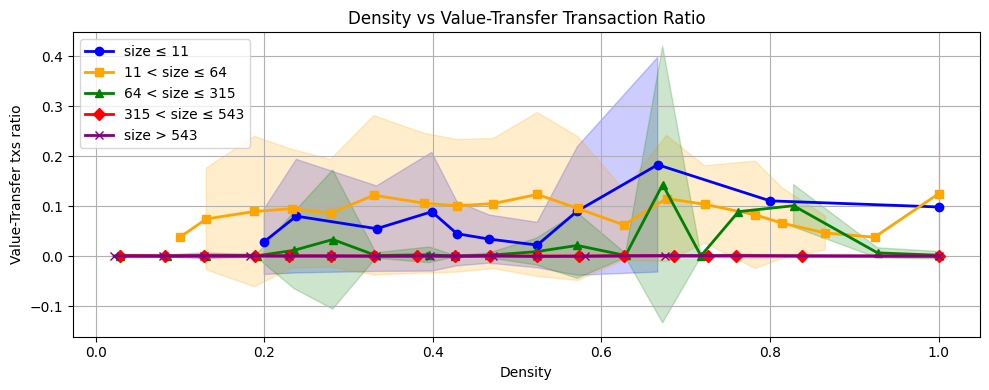

In [111]:
# Add checkpoint size
df_sizes = total_per_cp.reset_index()
df_sizes.columns = ["checkpoint", "size"]
df_merge = df_merge.merge(df_sizes, on="checkpoint", how="inner")

# Compute dynamic quantile thresholds
q25, q50, q75, q90 = np.percentile(df_merge["size"], [25, 50, 75, 90])
quantiles = [q25, q50, q75, q90]

labels = [
    f"size ≤ {q25:.0f}",
    f"{q25:.0f} < size ≤ {q50:.0f}",
    f"{q50:.0f} < size ≤ {q75:.0f}",
    f"{q75:.0f} < size ≤ {q90:.0f}",
    f"size > {q90:.0f}"
]
colors = ["blue", "orange", "green", "red", "purple"]
markers = ["o", "s", "^", "D", "x"]

df_merge['density_bin'] = pd.cut(df_merge['density'], bins=20)

plt.figure(figsize=(10,4))

for i, (low, high) in enumerate(zip([0]+quantiles, quantiles+[np.inf])):
    group = df_merge[(df_merge["size"] > low) & (df_merge["size"] <= high)]

    stats = group.groupby("density_bin")["pure_ratio"].agg(["mean", "std"])
    centers = group.groupby("density_bin")["density"].mean()

    # Align stats with centers
    stats = stats.reindex(centers.index)

    # Remove NaNs caused by empty bins
    mask = ~stats["mean"].isna()
    stats = stats[mask]
    centers = centers[mask]

    # Confidence band
    plt.fill_between(
        centers,
        stats["mean"] - stats["std"],
        stats["mean"] + stats["std"],
        alpha=0.2,
        color=colors[i]
    )

    # Line plot
    plt.plot(
        centers,
        stats["mean"],
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        label=labels[i]
    )

plt.xlabel("Density")
plt.ylabel("Value-Transfer txs ratio")
plt.title("Density vs Value-Transfer Transaction Ratio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Largest connected component (Parallelism lower bound)

In [ ]:
largest_cc = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        continue
    largest_cc[cp] = len(max(nx.connected_components(G), key=len))

Clique Number (Parallelism Upper Bound) (Using approximation algorithm)

In [ ]:
clique_sizes = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        continue
    clique_sizes[cp] = len(max_clique(G))


Graph Density

In [ ]:
density = {cp: nx.density(G) for cp, G in graphs.items()}

Degree Distribution (Detect Hub Objects)

In [ ]:
degrees = {}

for cp, G in graphs.items():
    degrees[cp] = dict(G.degree())

In [ ]:
max_degree = {}
mean_degree = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        max_degree[cp] = 0
        mean_degree[cp] = 0
        continue

    deg_values = [d for _, d in G.degree()]

    max_degree[cp] = max(deg_values)
    mean_degree[cp] = np.mean(deg_values)

Longest simple path

In [ ]:
longest_simple_path = {}

for cp, G in graphs.items():
    # Skip empty or trivial graphs
    if G.number_of_nodes() < 2:
        longest_simple_path[cp] = 0
        continue

    # LONGEST SIMPLE PATH (SAFE APPROXIMATION)
    # Use the maximum BFS eccentricity over all nodes
    ecc = nx.eccentricity(G)
    longest_simple_path[cp] = max(ecc.values())

Diameter

In [ ]:
diameter = {}

for cp, G in graphs.items():
    # Skip empty or trivial graphs
    if G.number_of_nodes() < 2:
        diameter[cp] = 0
        continue

    # DIAMETER (safe version: per connected component)
    if nx.is_connected(G):
        diameter[cp] = nx.diameter(G)
    else:
        diameter[cp] = max(
            nx.diameter(G.subgraph(c))
            for c in nx.connected_components(G)
            if len(c) > 1
        )

Chromatic number

In [ ]:
chromatic_number = {}

for cp, G in graphs.items():
    # Skip empty or trivial graphs
    if G.number_of_nodes() < 2:
        chromatic_number[cp] = 1 if G.number_of_nodes() == 1 else 0
        continue

    # CHROMATIC NUMBER (GREEDY APPROXIMATION)
    coloring = greedy_color(G, strategy="largest_first") 
    chromatic_number[cp] = len(set(coloring.values()))

Assortativity (measure of similarity) (in terms of node's degree)

In [ ]:
assortativity = {}

for cp, G in graphs.items():
    # Skip empty or trivial graphs
    if G.number_of_nodes() < 2:
        assortativity[cp] = 0
        continue

    # DEGREE ASSORTATIVITY
    try:
        assortativity[cp] = nx.degree_assortativity_coefficient(G)
    except:
        assortativity[cp] = 0

Concurrency Intensity, how many transactions wrote the same object in the same checkpoint. For hotspot detection, shared-object scalability analysis and parallelism limits

In [ ]:
cur.execute("""SELECT
    oc.address,
    c.sequence_number AS checkpoint,
    COUNT(DISTINCT oc.transaction_digest) AS concurrent_writers
FROM object_changes oc
JOIN transactions t
    ON oc.transaction_digest = t.transaction_digest
JOIN checkpoints c
    ON t.checkpoint_sequence = c.sequence_number
GROUP BY oc.address, c.sequence_number
HAVING COUNT(DISTINCT oc.transaction_digest) > 1
ORDER BY concurrent_writers DESC;
""")

Identify smart contract hotspots

In [ ]:
cur.execute("""SELECT address, COUNT(*)
FROM object_changes
WHERE change_type IN ('mutated')
GROUP BY address
ORDER BY COUNT(*) DESC
LIMIT 20;""")


Identify smart contract interaction graphs

In [ ]:
cur.execute("""SELECT kind, COUNT(*)
FROM transactions
GROUP BY kind;""")
